{'uci_id': 426, 'name': 'Autism Screening Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/426/autism+screening+adult', 'data_url': 'https://archive.ics.uci.edu/static/public/426/data.csv', 'abstract': 'Autistic Spectrum Disorder Screening Data for Adult. This dataset is related to classification and predictive tasks.', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': [], 'num_instances': 704, 'num_features': 20, 'feature_types': ['Integer'], 'demographics': ['Age', 'Gender', 'Ethnicity', 'Nationality'], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2017, 'last_updated': 'Thu Mar 28 2024', 'dataset_doi': '10.24432/C5F019', 'creators': ['Fadi Thabtah'], 'intro_paper': None, 'additional_info': {'summary': "See attached variables' description file ", 'purpose': None, 'funded_by': None, 'instances_represent': None, 'recommended_data_splits': None, 'sensitive_data': 

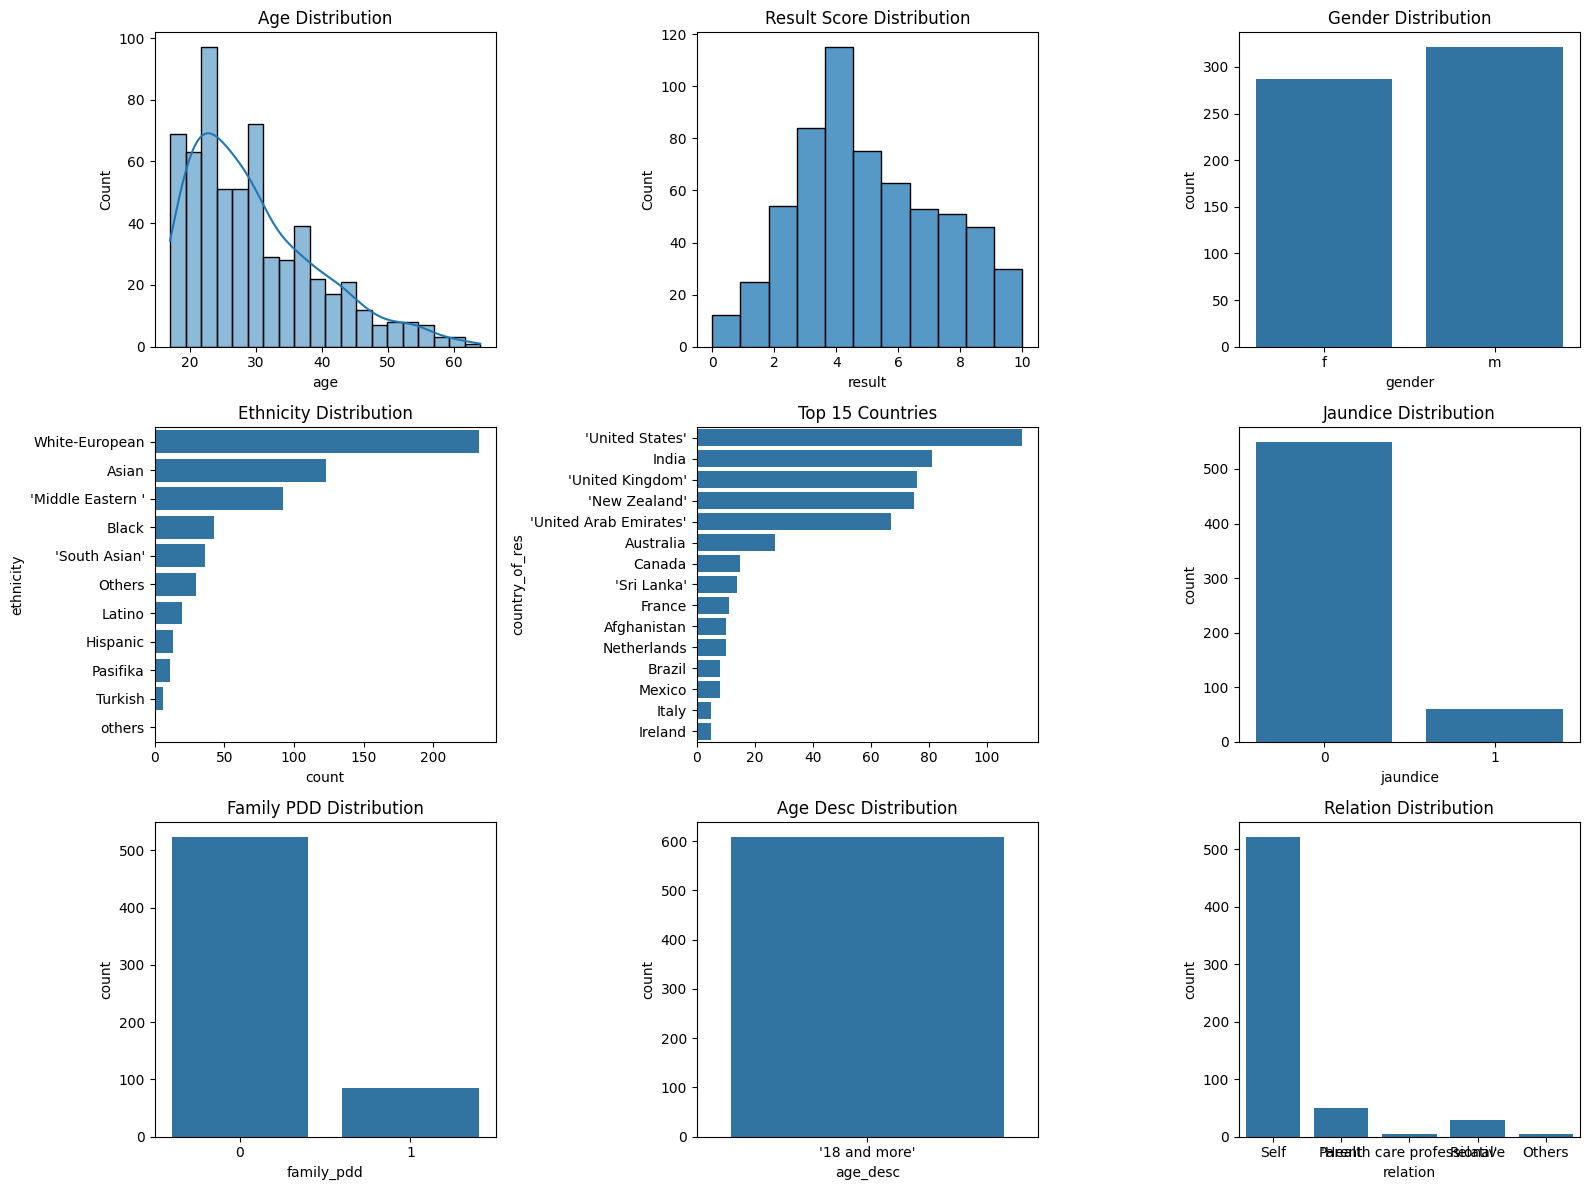

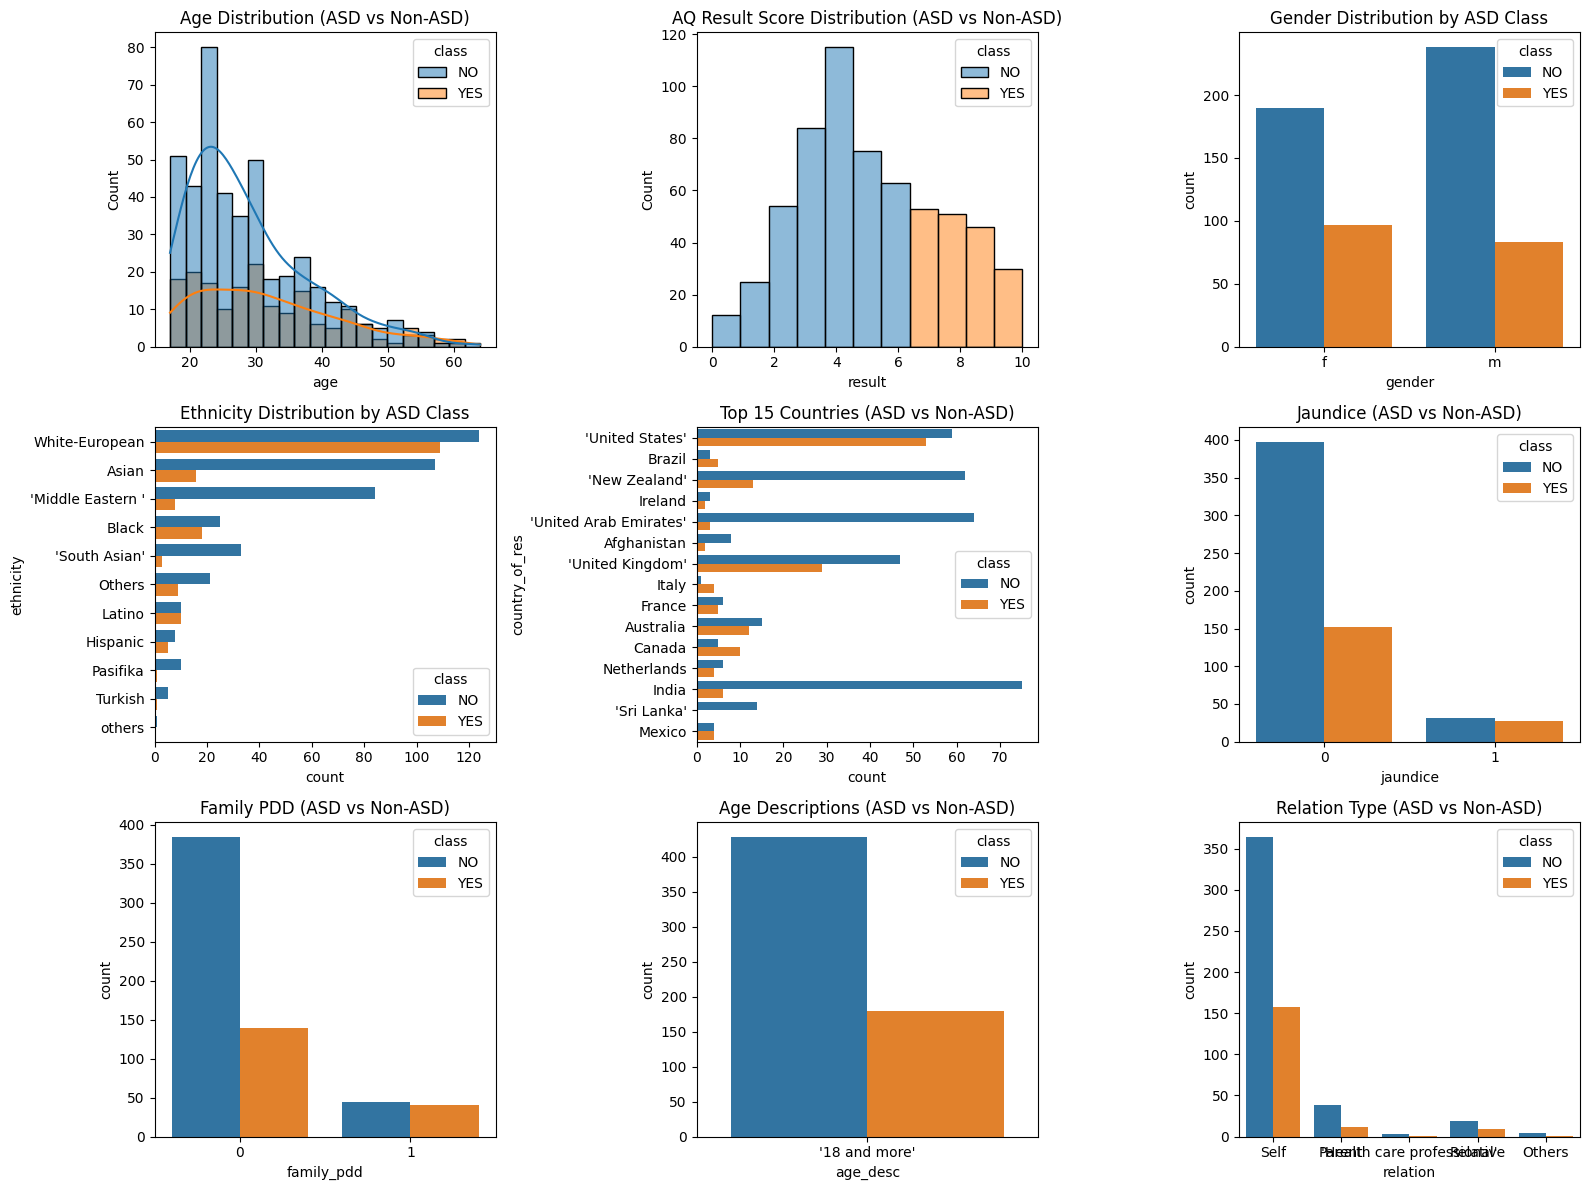

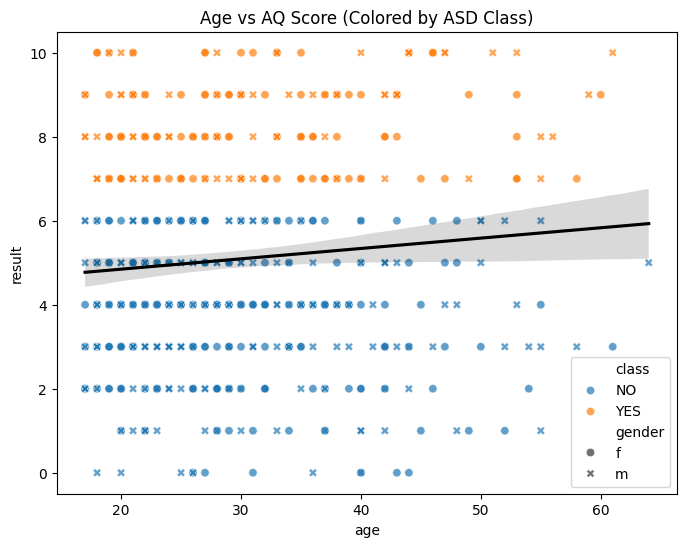

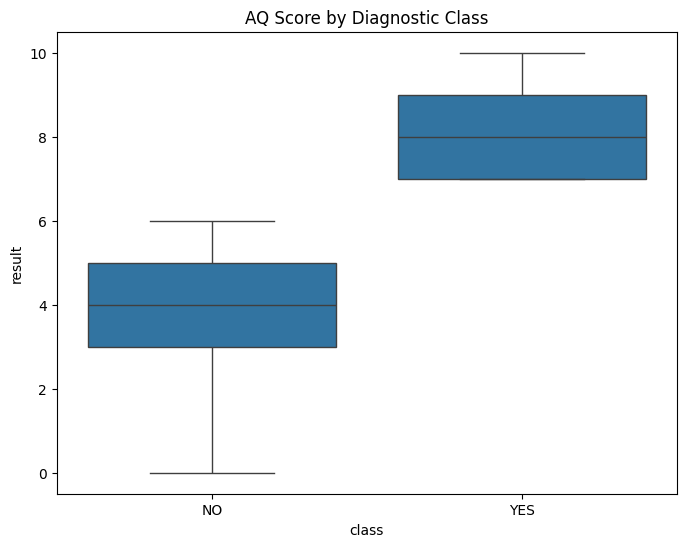

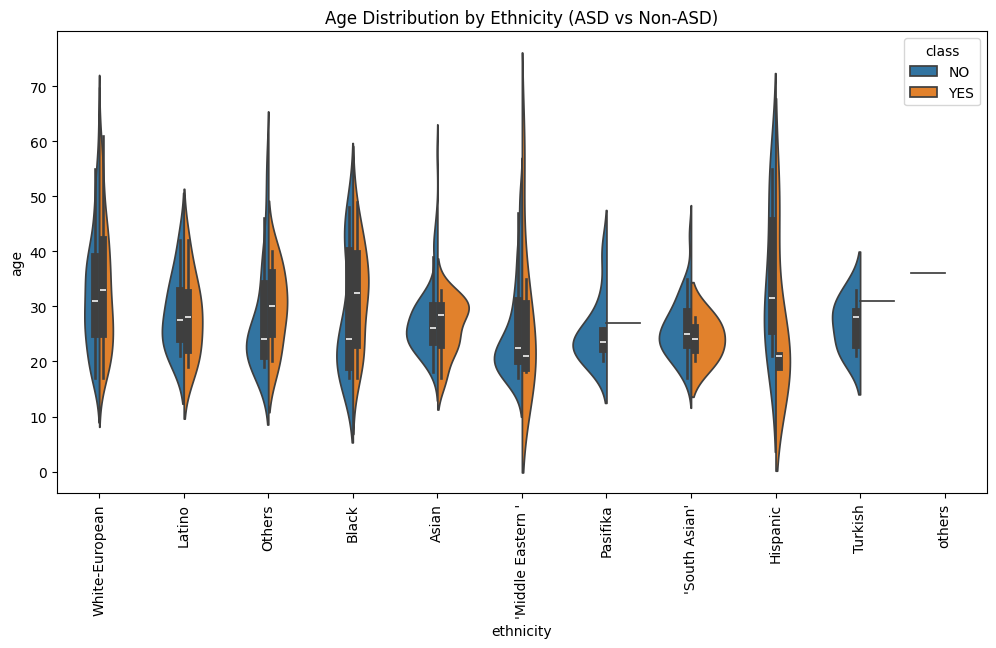

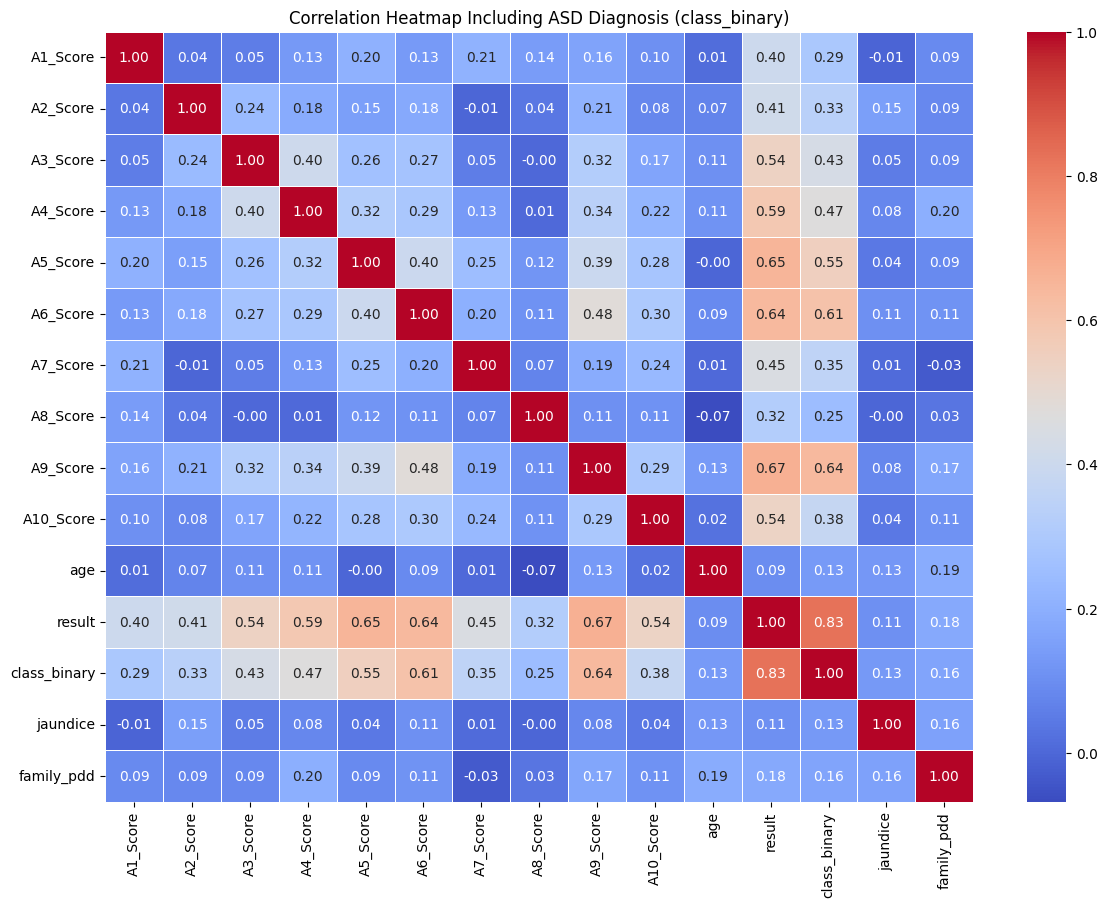

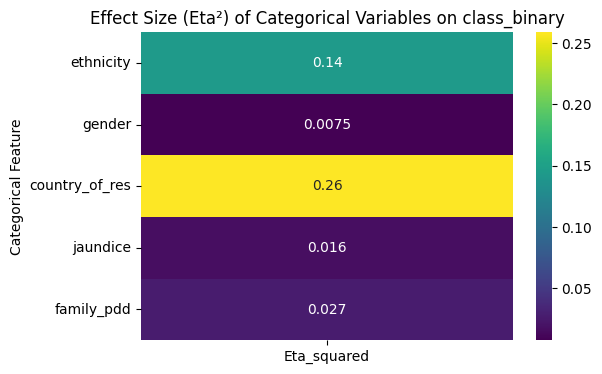

['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender', 'ethnicity', 'jaundice', 'family_pdd', 'country_of_res', 'used_app_before', 'result', 'age_desc', 'relation', 'class', 'class_binary']


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,family_pdd,country_of_res,used_app_before,result,age_desc,relation,class,class_binary
0,1,1,1,1,0,0,1,1,0,0,26.0,f,White-European,0,0,'United States',0,6,'18 and more',Self,NO,0
1,1,1,0,1,0,0,0,1,0,1,24.0,m,Latino,0,1,Brazil,0,5,'18 and more',Self,NO,0
2,1,1,0,1,1,0,1,1,1,1,27.0,m,Latino,1,1,Spain,0,8,'18 and more',Parent,YES,1
3,1,1,0,1,0,0,1,1,0,1,35.0,f,White-European,0,1,'United States',0,6,'18 and more',Self,NO,0
5,1,1,1,1,1,0,1,1,1,1,36.0,m,Others,1,0,'United States',0,9,'18 and more',Self,YES,1
6,0,1,0,0,0,0,0,1,0,0,17.0,f,Black,0,0,'United States',0,2,'18 and more',Self,NO,0
7,1,1,1,1,0,0,0,0,1,0,64.0,m,White-European,0,0,'New Zealand',0,5,'18 and more',Parent,NO,0
8,1,1,0,0,1,0,0,1,1,1,29.0,m,White-European,0,0,'United States',0,6,'18 and more',Self,NO,0
9,1,1,1,1,0,1,1,1,1,0,17.0,m,Asian,1,1,Bahamas,0,8,'18 and more','Health care professional',YES,1
10,1,1,1,1,1,1,1,1,1,1,33.0,m,White-European,0,0,'United States',0,10,'18 and more',Relative,YES,1


In [1]:
# import sys
# !{sys.executable} -m pip install ucimlrepo
import warnings
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
import plotly.graph_objects as go
from ucimlrepo import fetch_ucirepo 
from ipywidgets import interact, Dropdown
  
#Configure DataFrame Display Options
def force_display_dataframe_config():
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', None) 

#Configure DataFrame Displya Options (Default):
def default_dataframe_config():
    pd.reset_option('display.max_rows')
    pd.reset_option('display.max_columns')
    pd.reset_option('display.width')
    pd.reset_option('display.max_colwidth')

#Pull University Irvine Adult Autism Dataset
def fetch_data_set():
    autism_screening_adult = fetch_ucirepo(id=426) 
    X = autism_screening_adult.data.features 
    y = autism_screening_adult.data.targets 
    print(autism_screening_adult.metadata) 
    print(autism_screening_adult.variables)
    return autism_screening_adult

def parse_dataset_into_dataframe(ds):
    #Force parse the information into a DataFrame for easier manipulation.
    autism_screening_adult = fetch_data_set()
    df = pd.concat([autism_screening_adult.data.features, autism_screening_adult.data.targets], axis=1)
    print(df.info())
    return df

def clean_dataframe(df):
    #Cleanup
    #df.isna().sum()
    initial_rows = len(df)
    print(f"Initial number of rows: {initial_rows}")
    print("\nMissing values per column BEFORE cleanup:")
    print(df.isna().sum())
    df = df.replace({"?": None, "NA": None, "N/A": None, "Unknown": None})
    df = df.dropna()
    df = df[df['age'] != 383.0]
    final_rows = len(df)
    print(f"\nFinal number of rows after cleanup: {final_rows}")
    print(f"Total rows removed: {initial_rows - final_rows}")

    df['class_binary'] = df['class'].map({'YES': 1, 'NO': 0}).astype(int)
    df['jaundice'] = df['jaundice'].map({'yes': 1, 'no': 0}).astype(int)
    df['family_pdd'] = df['family_pdd'].map({'yes': 1, 'no': 0}).astype(int)
    df['used_app_before'] = df['used_app_before'].map({'yes': 1, 'no': 0}).astype(int)
    
    return df

def plot_distributions(df):
    # Ensure plots render inline

    # Assuming your dataframe is called df
    # Clean missing values for plotting
    df_clean = df.copy()
    df_clean = df_clean.replace({"?": None, "NA": None, "N/A": None, "Unknown": None})
    df_clean = df_clean.dropna(subset=['age', 'gender', 'ethnicity', 'country_of_res', 'relation', 'result'])

    # -----------------------------
    # 1. Distribution plots
    # -----------------------------
    plt.figure(figsize=(16, 12))

    # Age histogram
    plt.subplot(3,3,1)
    sns.histplot(df_clean['age'], bins=20, kde=True)
    plt.title("Age Distribution")

    # Result score histogram
    plt.subplot(3,3,2)
    sns.histplot(df_clean['result'], bins=11, kde=False)
    plt.title("Result Score Distribution")

    # Gender distribution
    plt.subplot(3,3,3)
    sns.countplot(x='gender', data=df_clean)
    plt.title("Gender Distribution")

    # Ethnicity distribution
    plt.subplot(3,3,4)
    sns.countplot(y='ethnicity', data=df_clean, order=df_clean['ethnicity'].value_counts().index)
    plt.title("Ethnicity Distribution")

    # Country top 15
    plt.subplot(3,3,5)
    top_countries = df_clean['country_of_res'].value_counts().nlargest(15)
    sns.barplot(x=top_countries.values, y=top_countries.index)
    plt.title("Top 15 Countries")

    # Jaundice distribution
    plt.subplot(3,3,6)
    sns.countplot(x='jaundice', data=df_clean)
    plt.title("Jaundice Distribution")

    # Family_pdd distribution
    plt.subplot(3,3,7)
    sns.countplot(x='family_pdd', data=df_clean)
    plt.title("Family PDD Distribution")

    # Age_desc distribution
    plt.subplot(3,3,8)
    sns.countplot(x='age_desc', data=df_clean)
    plt.title("Age Desc Distribution")

    # Relation distribution
    plt.subplot(3,3,9)
    sns.countplot(x='relation', data=df_clean)
    plt.title("Relation Distribution")

    plt.tight_layout()
    plt.show()


def plot_distributions1(df_clean):
    required_cols = [
        'age', 'gender', 'ethnicity', 'country_of_res', 
        'relation', 'result', 'class'
    ]
    df_clean = df_clean.dropna(subset=required_cols)

    
    #========================================
    # 1) BASIC DISTRIBUTIONS
    #========================================
    plt.figure(figsize=(16, 12))

    # ---- Age distribution (by ASD class) ----
    plt.subplot(3,3,1)
    sns.histplot(data=df_clean, x='age', hue='class', kde=True, bins=20)
    plt.title("Age Distribution (ASD vs Non-ASD)")

    # ---- Result score distribution by class ----
    plt.subplot(3,3,2)
    sns.histplot(data=df_clean, x='result', hue='class', kde=False, bins=11)
    plt.title("AQ Result Score Distribution (ASD vs Non-ASD)")

    # ---- Gender distribution by class ----
    plt.subplot(3,3,3)
    sns.countplot(data=df_clean, x='gender', hue='class')
    plt.title("Gender Distribution by ASD Class")

    # ---- Ethnicity distribution by class ----
    plt.subplot(3,3,4)
    sns.countplot(data=df_clean, y='ethnicity', hue='class',
                  order=df_clean['ethnicity'].value_counts().index)
    plt.title("Ethnicity Distribution by ASD Class")

    # ---- Top 15 countries ----
    plt.subplot(3,3,5)
    top_countries = df_clean['country_of_res'].value_counts().nlargest(15).index
    sns.countplot(data=df_clean[df_clean['country_of_res'].isin(top_countries)],
                  y='country_of_res', hue='class')
    plt.title("Top 15 Countries (ASD vs Non-ASD)")

    # ---- Jaundice ----
    plt.subplot(3,3,6)
    sns.countplot(data=df_clean, x='jaundice', hue='class')
    plt.title("Jaundice (ASD vs Non-ASD)")

    # ---- Family PDD ----
    plt.subplot(3,3,7)
    sns.countplot(data=df_clean, x='family_pdd', hue='class')
    plt.title("Family PDD (ASD vs Non-ASD)")

    # ---- Age Description ----
    plt.subplot(3,3,8)
    sns.countplot(data=df_clean, x='age_desc', hue='class')
    plt.title("Age Descriptions (ASD vs Non-ASD)")

    # ---- Relation ----
    plt.subplot(3,3,9)
    sns.countplot(data=df_clean, x='relation', hue='class')
    plt.title("Relation Type (ASD vs Non-ASD)")

    plt.tight_layout()
    plt.show()


    #========================================
    # 2) RELATIONSHIPS
    #========================================

    # ---- Age vs AQ Score ----
    plt.figure(figsize=(8,6))
    sns.scatterplot(
        x='age', y='result', hue='class', 
        style='gender', alpha=0.7, data=df_clean
    )
    sns.regplot(x='age', y='result', data=df_clean, scatter=False, color='black')
    plt.title("Age vs AQ Score (Colored by ASD Class)")
    plt.show()

    # ---- Boxplot AQ by class ----
    plt.figure(figsize=(8,6))
    sns.boxplot(data=df_clean, x='class', y='result')
    plt.title("AQ Score by Diagnostic Class")
    plt.show()

    # ---- Violin: Age by Ethnicity & Class ----
    plt.figure(figsize=(12,6))
    sns.violinplot(
        data=df_clean, x='ethnicity', y='age', hue='class', split=True
    )
    plt.xticks(rotation=90)
    plt.title("Age Distribution by Ethnicity (ASD vs Non-ASD)")
    plt.show()


    #========================================
    # 3) CORRELATION HEATMAP (NUMERIC ONLY)
    #========================================

    numeric_cols = [
        'A1_Score','A2_Score','A3_Score','A4_Score','A5_Score',
        'A6_Score','A7_Score','A8_Score','A9_Score','A10_Score',
        'age','result','class_binary', 'jaundice', 'family_pdd'
    ]

    plt.figure(figsize=(14, 10))
    sns.heatmap(
        df_clean[numeric_cols].corr(), 
        annot=True, fmt=".2f", cmap='coolwarm', 
        cbar=True, linewidths=0.5
    )
    plt.title("Correlation Heatmap Including ASD Diagnosis (class_binary)")
    plt.show()


def plot_categorical_effects_on_asd(df, target_col='class_binary', 
                                    categorical_features=None, figsize=(6,4)):
    """
    Computes Eta² effect size for categorical variables vs a binary ASD target
    and plots a heatmap.

    Parameters:
    -----------
    df : pd.DataFrame
        The dataframe containing your dataset.
    target_col : str
        The column representing ASD diagnosis (binary: 0/1)
    categorical_features : list of str
        List of categorical features to analyze. If None, defaults will be used.
    figsize : tuple
        Figure size for the heatmap.

    Returns:
    --------
    results_df : pd.DataFrame
        DataFrame with Eta² effect sizes for each categorical variable.
    """

    # Default categorical features if none provided
    if categorical_features is None:
        categorical_features = ["ethnicity", "gender", "country_of_res", 
                                "jaundice", "family_pdd"]

    # Function to calculate Eta²
    def eta_squared(aov_table):
        return aov_table["sum_sq"][0] / aov_table["sum_sq"].sum()

    results = {}

    # Run ANOVA for each categorical feature
    for col in categorical_features:
        formula = f"{target_col} ~ C({col})"
        model = ols(formula, data=df).fit()
        aov_table = sm.stats.anova_lm(model, typ=2)
        results[col] = eta_squared(aov_table)

    # Convert to DataFrame
    results_df = pd.DataFrame.from_dict(results, orient='index', columns=["Eta_squared"])

    # Plot heatmap
    plt.figure(figsize=figsize)
    sns.heatmap(results_df, annot=True, cmap="viridis", cbar=True)
    plt.title(f"Effect Size (Eta²) of Categorical Variables on {target_col}")
    plt.ylabel("Categorical Feature")
    plt.show()

    return results_df



def interactive_plot(df_clean):
    # Scatter: Age vs Result, colored by Gender
    fig1 = px.scatter(df_clean, x='age', y='result', color='gender', 
                    hover_data=['ethnicity','country_of_res','relation'],
                    title="Age vs Result Score by Gender")
    fig1.show()

    # Boxplot: Age by Ethnicity
    fig2 = px.box(df_clean, x='ethnicity', y='age', color='gender',
                points="all", hover_data=['country_of_res','relation'],
                title="Age Distribution by Ethnicity")
    fig2.update_layout(xaxis_tickangle=-45)
    fig2.show()

    # Bar plot: Gender distribution by Class
    if 'class' in df_clean.columns:
        fig3 = px.bar(df_clean, x='gender', color='class', 
                    title="Gender Distribution by Class", barmode='group')
        fig3.show()

    # Bar plot: Top 15 Countries
    # top_countries = df_clean['country_of_res'].value_counts().nlargest(15).reset_index()
    # fig4 = px.bar(top_countries, x='index', y='country_of_res', 
    #             title="Top 15 Countries", labels={'index':'Country','country_of_res':'Count'})
    # fig4.show()

    # Interactive heatmap for numeric correlations
    corr = df_clean[numeric_cols].corr()
    fig5 = go.Figure(data=go.Heatmap(
        z=corr.values,
        x=corr.columns,
        y=corr.index,
        colorscale='RdBu',
        zmin=-1, zmax=1
    ))
    fig5.update_layout(title="Correlation Heatmap (Numeric Features)")
    fig5.show()





# ----------------- Notebook Main Program Control --------------------------
warnings.filterwarnings("ignore")
force_display_dataframe_config()
#default_dataframe_config()
ds = fetch_data_set()
df = parse_dataset_into_dataframe(ds)
df = clean_dataframe(df)
%matplotlib inline
plot_distributions(df)
plot_distributions1(df)
plot_categorical_effects_on_asd(df)
#interactive_plot(df)
print(list(df.columns))
df

## What is this cell trying to do?

You already have a table (`df`) where each row is a person, and you know if they are labeled ASD (yes/no). The cell asks: **if we use the questionnaire answers (A1–A10) plus a few other columns (age, country, etc.), can a computer do a decent job matching that label, and which columns help the most?**

That’s it. It’s not proving medical truth—it’s **measuring which columns the model leans on** when it tries to **copy the YES/NO label**.

## What goes in (inputs)

- **`X`:** “Things we are allowed to look at to guess the label”
  - The 10 item scores (A1…A10), age, and some categories (gender, ethnicity, country, etc.).
- **`y`:** “The answer we want to predict”
  - `class_binary`: 1 = YES (ASD in this dataset’s coding), 0 = NO.
- **`result`** is not used as an input, because in your project you care about **items and metadata**; `result` is too close to a summary of the same items and would make the story messier.

## Step 1: Turn messy columns into numbers the model can eat

- Numbers (scores, age, etc.) are **scaled** so that “age 30” and “A3 = 1” aren’t on totally different numeric scales in a way that confuses distance-based bits of the model.
- Text categories (e.g. country) are **one-hot encoded:** each category becomes a bunch of 0/1 columns like “is this country Jordan yes/no”.

> **Plain English:** we’re not changing meaning; we’re **reformatting** the table for the algorithm.

## Step 2: One fixed type of “guesser” (the model)

It uses a **Random Forest:** many decision trees that vote. You don’t need to know how a tree works—think **“a bunch of if/then rules learned from the data.”**

> **Plain English:** one chosen model, not ten different ones.

## Step 3: “Did it work?” (cross-validation)

The data is split **5** times in a **stratified** way: each fold keeps roughly the same proportion of YES/NO.

For each split the model is trained on part of the rows and tested on the rest, so the scores are **out-of-fold** (more honest than “train and test on the same rows”).

> **Plain English:** “If we pretend we don’t know some answers, how often is the model right?” It prints things like **AUROC**, **F1**, **precision**, **recall**—all are summary grades of how well the guesser matches the real labels. You only need the intuition: **higher = generally better match**, and you’re looking at **mean ± spread** over the 5 runs.

## Step 4: “What did it actually use?” (permutation importance)

This is the **heart** of your project question.

For each input column, the code **repeatedly shuffles** that column’s values (so it becomes garbage that doesn’t match the person anymore) and measures how much worse the model gets (here: how much **AUROC** drops).

> **Plain English:**
> - If shuffling a column **barely changes** performance → the model **wasn’t really relying** on that column.
> - If shuffling a column **hurts a lot** → that column **mattered** for its guesses.

It **averages** this over the 5 test folds and draws a **horizontal bar chart** so you can see which of **A1–A10** and which **metadata** fields show up on top.

## Step 5: “Is the order of the A-questions stable?” (Spearman bit)

It compares, across different folds, the **ranking** of importance for **only A1–A10** (not the other columns). **Spearman** = “do the *order* of items match between folds?”

> **Plain English:** if every fold says “A4 and A7 near the top, A2 at the bottom,” you **trust the story more** than if the order **jumps randomly**.

## Step 6: SHAP (optional, if the library is installed)

**SHAP** tries to show **per feature** (and per one-hot level) how much that feature **pushed** the prediction up or down for many rows. It uses the same trained forest, but in the **transformed** space (so you may see `country_X`, `ethnicity_Y` as separate lines).

> **Plain English:** **permutation importance** = “how much does the model **need** this column **overall**?”
> **SHAP** = “for these example rows, **who pushed** the score up or down?” The cell does **permutation** as the main story and **SHAP** as an extra picture if `shap` is installed.

## What you should look at as a “student”

1. The **printed table** of permutation importance: which **A*** items and which **metadata** float to the top.
2. The **bar chart:** same information, easier to read.
3. The **CV numbers:** one paragraph in your report: “single RF, 5-fold, roughly X AUROC, etc.”
4. **SHAP** only if you installed it and you’re OK explaining that categories **split into many lines**.

*If you get stuck on one line of code (e.g. `clone(pipe)` or `StratifiedKFold`), check the [scikit-learn](https://scikit-learn.org) docs for that name, or ask for a one-line explanation.*


Stratified 5-fold (mean ± std) — OOF:
  f1          0.927 ± 0.029
  precision   0.932 ± 0.023
  recall      0.922 ± 0.041
  roc_auc     0.994 ± 0.003
n = 608, prevalence P(ASD) = 0.296

Permutation importance (higher = more important for AUROC), fold-averaged:
        feature  importance_mean  importance_std
       A5_Score         0.025396        0.008794
       A9_Score         0.017538        0.004544
       A4_Score         0.010331        0.004203
       A6_Score         0.009694        0.002603
       A7_Score         0.008262        0.002150
       A3_Score         0.007165        0.003006
       A1_Score         0.006296        0.002871
       A8_Score         0.006092        0.002199
       A2_Score         0.005676        0.002334
      A10_Score         0.005045        0.002659
 country_of_res         0.000442        0.000432
       relation         0.000122        0.000153
       jaundice         0.000017        0.000136
used_app_before         0.000004        0.000009
    

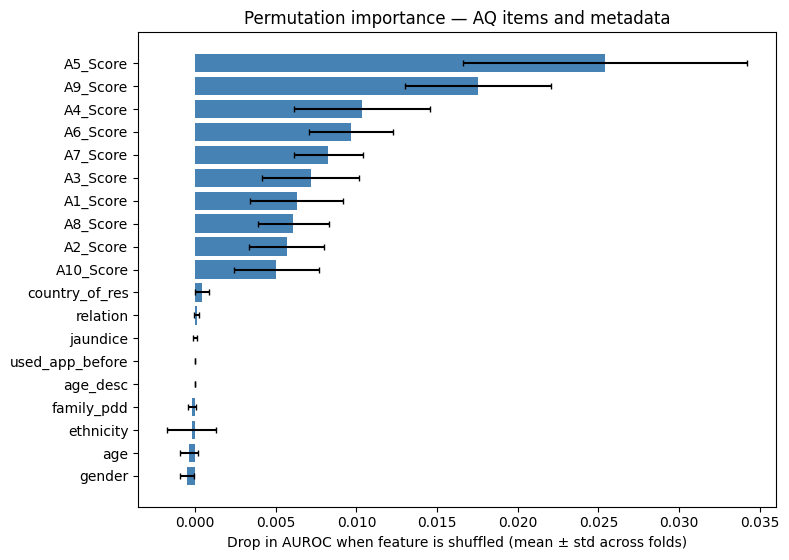


Spearman rank correlation of A1–A10 importances (pairwise CV folds):
  mean = 0.608  (1.0 = stable item order across folds)

(Install shap for summary plot: pip install shap)


In [2]:
# Goal: one supervised model (Random Forest) + which features matter (permutation, optional SHAP).
# OOF = out-of-fold scores. We do NOT use `result` or the raw label text as inputs.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone  # unfitted copy of `pipe` for each CV fold
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

if "df" not in globals() or not isinstance(globals().get("df"), pd.DataFrame):
    raise RuntimeError("Run the cell above so the cleaned `df` is defined.")

# --- Build X (features) and y (0/1 target) ---
TARGET = "class_binary"  # 1 = YES, 0 = NO in cleaned data
ITEM_COLS = [f"A{i}_Score" for i in range(1, 11)]  # AQ-10 item scores
NUMERIC = ITEM_COLS + ["age", "jaundice", "family_pdd", "used_app_before"]
CATEGORICAL = ["gender", "ethnicity", "country_of_res", "age_desc", "relation"]
missing = [c for c in (NUMERIC + CATEGORICAL) if c not in df.columns]
if missing:
    raise KeyError(f"Expected columns not in df: {missing}")
FEATS = [c for c in NUMERIC + CATEGORICAL if c in df.columns]
X = df[FEATS].copy()  # design matrix: items + age + context + metadata
y = df[TARGET].astype(int)

# --- Preprocess: z-score numbers; one-hot categories (name differs in old sklearn) ---
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

pre = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), [c for c in NUMERIC if c in X.columns]),
        ("cat", ohe, [c for c in CATEGORICAL if c in X.columns]),
    ],
    verbose_feature_names_out=False,
)
RANDOM_STATE = 42
clf = RandomForestClassifier(
    n_estimators=300,  # more trees → lower variance, slower
    max_depth=12,
    min_samples_leaf=2,
    class_weight="balanced",  # upweight rare class (ASD) in loss
    random_state=RANDOM_STATE,
    n_jobs=-1,  # use all CPU cores
)
pipe = Pipeline([("pre", pre), ("clf", clf)])

# --- 5-fold stratified CV: same proportion of 0/1 in each train fold ---
scoring = {"roc_auc": "roc_auc", "f1": "f1", "precision": "precision", "recall": "recall"}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv = cross_validate(pipe, X, y, cv=skf, scoring=scoring, n_jobs=-1, return_train_score=False)
print("Stratified 5-fold (mean ± std) — OOF:")
for k in sorted(scoring.keys()):
    m, s = cv[f"test_{k}"].mean(), cv[f"test_{k}"].std()  # mean/std across the 5 held-out folds
    print(f"  {k:10s}  {m:.3f} ± {s:.3f}")
print(f"n = {len(y)}, prevalence P(ASD) = {y.mean():.3f}")

# --- Permutation importance: for each column, random shuffle on TEST fold → measure AUROC hit ---
importances = []  # one vector of mean importances per fold
n_rep = 15  # repeated shuffles per feature per fold (stabilize the number)
for train_idx, test_idx in skf.split(X, y):
    m = clone(pipe)  # new unfitted pipeline for this split
    m.fit(X.iloc[train_idx], y.iloc[train_idx])
    pi = permutation_importance(
        m,
        X.iloc[test_idx],
        y.iloc[test_idx],
        n_repeats=n_rep,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scoring="roc_auc",  # drop in AUROC when this column is permuted to noise
    )
    importances.append(pi.importances_mean)
imp = np.vstack(importances)  # shape: (n_folds, n_features in X)
feat_names = list(X.columns)
imp_df = (
    pd.DataFrame({"feature": feat_names, "importance_mean": imp.mean(0), "importance_std": imp.std(0)})
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)
print("\nPermutation importance (higher = more important for AUROC), fold-averaged:")
print(imp_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, max(3, 0.3 * len(feat_names))))  # taller fig if many features
ax.barh(imp_df["feature"], imp_df["importance_mean"], xerr=imp_df["importance_std"], capsize=2, color="steelblue")
ax.invert_yaxis()  # best features at the top of the plot
ax.set_xlabel("Drop in AUROC when feature is shuffled (mean ± std across folds)")
ax.set_title("Permutation importance — AQ items and metadata")
fig.tight_layout()
plt.show()

# --- Spearman: do A1–A10 *ranks* of importance match across fold pairs? (1 = stable) ---
item_idx = [i for i, fn in enumerate(feat_names) if fn in ITEM_COLS]
if len(item_idx) >= 2:
    from scipy.stats import spearmanr
    R = []
    for a in range(len(importances)):
        for b in range(a + 1, len(importances)):
            va = [importances[a][i] for i in item_idx]
            vb = [importances[b][i] for i in item_idx]
            R.append(spearmanr(va, vb).correlation)
    print("\nSpearman rank correlation of A1–A10 importances (pairwise CV folds):")
    print(f"  mean = {float(np.mean(R)):.3f}  (1.0 = stable item order across folds)")

# --- Optional SHAP: explain the same forest on transformed (one-hot) columns ---
try:
    import shap
except ImportError:
    shap = None
    print("\n(Install shap for summary plot: pip install shap)")
if shap is not None:
    pipe.fit(X, y)  # fit on all rows for one global explainer
    X_t = pipe.named_steps["pre"].transform(X)  # scaled + one-hot matrix
    feat_out = pipe.named_steps["pre"].get_feature_names_out()  # names after preprocessing
    bg = shap.utils.sample(X_t, 100, random_state=RANDOM_STATE)  # small background for TreeExplainer
    expl = shap.TreeExplainer(pipe.named_steps["clf"], data=bg, feature_perturbation="tree_path_dependent")
    X_e = shap.utils.sample(X_t, min(200, X_t.shape[0]), random_state=RANDOM_STATE)  # rows to explain
    shap_values = expl.shap_values(X_e, check_additivity=False)
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values  # positive class (ASD)
    plt.figure(figsize=(8, 6))
    shap.summary_plot(sv, X_e, feature_names=feat_out, show=True, max_display=20)
